# Phase 3 — TF-IDF Text Features

Convert cleaned titles (`name_clean`) into a sparse TF-IDF matrix capped at 2,500 features(top 2,500 most informative words). Fit the vectorizer on the training split only to avoid leakage.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path("..").resolve()
IN_PATH = ROOT / "data" / "interim" / "ks_text_cleaned.csv"
OUT_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reports" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

MAX_FEATURES = 2500
TEST_SIZE = 0.2
RANDOM_STATE = 42

## 1. Load cleaned text

In [2]:
df = pd.read_csv(IN_PATH)
df["name_clean"] = df["name_clean"].fillna("").astype(str)
print(f"rows: {len(df):,} | success rate: {df['target'].mean():.3f}")
df[["ID", "name_clean", "target"]].head()

rows: 330,911 | success rate: 0.404


,ID,name_clean,target
0,1000002330,songs adelaide abullah,0
1,1000003930,greeting earth zgac arts capsule et,0
2,1000004038,hank,0
3,1000007540,toshicapital rekordz needs help complete album,0
4,1000014025,monarch espresso bar,1


## 2. Stratified train / test split

Split first, then fit TF-IDF on train only. Save IDs so later tabular and fusion steps use the same rows.

In [3]:
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["target"],
)

split_summary = pd.DataFrame(
    {
        "rows": [len(train_df), len(test_df)],
        "success_rate": [train_df["target"].mean(), test_df["target"].mean()],
    },
    index=["train", "test"],
).round(3)
split_summary

,rows,success_rate
train,264728,0.404
test,66183,0.404


### What this split shows

An 80/20 stratified split keeps the failed/successful mix nearly identical in train and test, so evaluation stays honest when we add tabular features and fuse matrices later.

## 3. Fit TF-IDF on train, transform both splits

In [4]:
vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=(1, 1),
    min_df=2,
    dtype=np.float32,
)

X_train = vectorizer.fit_transform(train_df["name_clean"])
X_test = vectorizer.transform(test_df["name_clean"])

y_train = train_df["target"].to_numpy(dtype=np.int8)
y_test = test_df["target"].to_numpy(dtype=np.int8)
feature_names = np.array(vectorizer.get_feature_names_out())

print(f"X_train: {X_train.shape} | density: {X_train.nnz / np.prod(X_train.shape):.6f}")
print(f"X_test:  {X_test.shape} | density: {X_test.nnz / np.prod(X_test.shape):.6f}")
print(f"vocab size: {len(feature_names):,}")

X_train: (264728, 2500) | density: 0.001027
X_test:  (66183, 2500) | density: 0.001023
vocab size: 2,500


### What this matrix shows

We get sparse matrices shaped roughly `[N × 2500]`. Density is very low because each title only activates a handful of tokens — this is why sparse storage matters before fusion.

## 4. Inspect top IDF terms

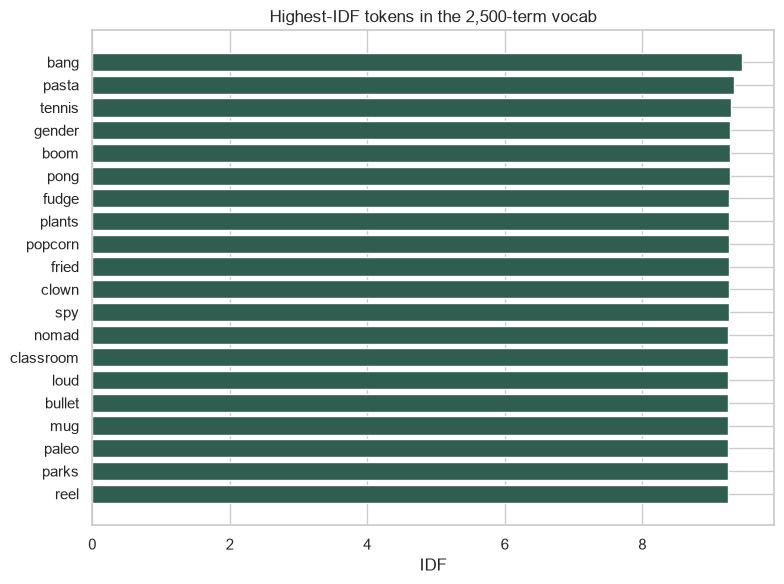

,token,idf
0,bang,9.443411
1,pasta,9.327579
2,tennis,9.296807
3,gender,9.281770
4,boom,9.281770
5,pong,9.281770
6,fudge,9.266954
7,plants,9.266954
8,popcorn,9.266954
9,fried,9.266954


In [5]:
idf_table = (
    pd.DataFrame({"token": feature_names, "idf": vectorizer.idf_})
    .sort_values("idf", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, 6))
top_idf = idf_table.head(20).iloc[::-1]
ax.barh(top_idf["token"], top_idf["idf"], color="#2f5d50")
ax.set_title("Highest-IDF tokens in the 2,500-term vocab")
ax.set_xlabel("IDF")
plt.tight_layout()
fig.savefig(FIG_DIR / "03_top_idf_tokens.png", dpi=150)
plt.show()

idf_table.head(10)

### What this figure shows

Highest-IDF tokens are rare in the corpus (more campaign-specific). Common genre words tend to get lower IDF and will rely more on term frequency when the classifier learns weights.

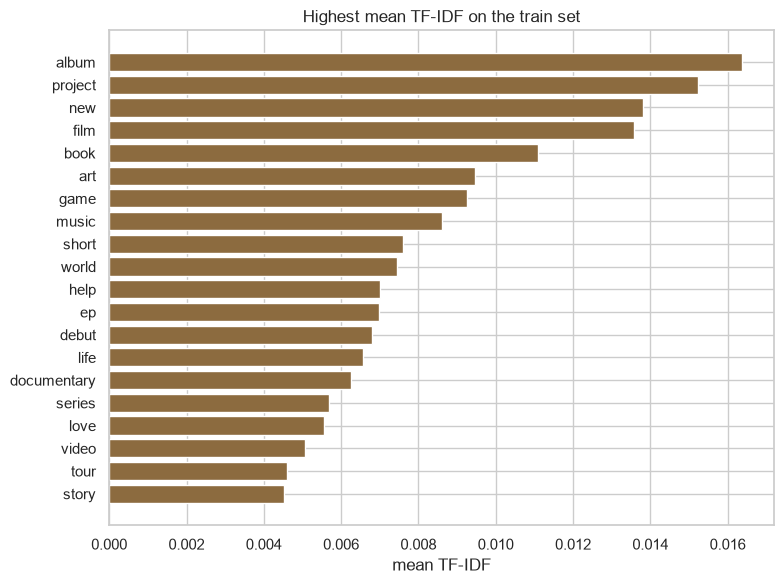

,token,mean_tfidf
0,album,0.016379
1,project,0.015242
2,new,0.013807
3,film,0.013575
4,book,0.011097
5,art,0.009466
6,game,0.009263
7,music,0.008609
8,short,0.007595
9,world,0.007434


In [6]:
mean_tfidf = np.asarray(X_train.mean(axis=0)).ravel()
mean_table = (
    pd.DataFrame({"token": feature_names, "mean_tfidf": mean_tfidf})
    .sort_values("mean_tfidf", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, 6))
plot_df = mean_table.iloc[::-1]
ax.barh(plot_df["token"], plot_df["mean_tfidf"], color="#8c6b3f")
ax.set_title("Highest mean TF-IDF on the train set")
ax.set_xlabel("mean TF-IDF")
plt.tight_layout()
fig.savefig(FIG_DIR / "03_top_mean_tfidf_tokens.png", dpi=150)
plt.show()

mean_table

### What this figure shows

High mean TF-IDF tokens are frequent content words across many titles (for example media/project nouns). Together with rare high-IDF terms, they form the text side of the fused feature space.

## 5. Save processed text artifacts

In [7]:
sparse.save_npz(OUT_DIR / "X_text_train.npz", X_train)
sparse.save_npz(OUT_DIR / "X_text_test.npz", X_test)
np.save(OUT_DIR / "y_train.npy", y_train)
np.save(OUT_DIR / "y_test.npy", y_test)

pd.DataFrame({"token": feature_names}).to_csv(OUT_DIR / "tfidf_feature_names.csv", index=False)
joblib.dump(vectorizer, OUT_DIR / "tfidf_vectorizer.joblib")

split_ids = pd.concat(
    [
        train_df[["ID"]].assign(split="train"),
        test_df[["ID"]].assign(split="test"),
    ],
    ignore_index=True,
)
split_ids.to_csv(OUT_DIR / "split_ids.csv", index=False)

meta = {
    "source": str(IN_PATH.name),
    "max_features": MAX_FEATURES,
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "n_train": int(X_train.shape[0]),
    "n_test": int(X_test.shape[0]),
    "n_features": int(X_train.shape[1]),
    "train_density": float(X_train.nnz / np.prod(X_train.shape)),
    "test_density": float(X_test.nnz / np.prod(X_test.shape)),
}
with open(OUT_DIR / "tfidf_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print("saved to", OUT_DIR)
meta

saved to /Users/koriginjasathvik/Desktop/ML_Summer_Project/data/processed


{'source': 'ks_text_cleaned.csv',
 'max_features': 2500,
 'test_size': 0.2,
 'random_state': 42,
 'n_train': 264728,
 'n_test': 66183,
 'n_features': 2500,
 'train_density': 0.0010274742377081381,
 'test_density': 0.0010226795400631581}

## Phase 3 takeaways

- TF-IDF capped at 2,500 features from `name_clean`.
- Vectorizer fitted on train only; test is transform-only.
- Sparse outputs: `X_text_train.npz`, `X_text_test.npz`.
- Shared split IDs saved for tabular alignment in Phase 4+.
- Notes: [`docs/tfidf.md`](../docs/tfidf.md).